# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

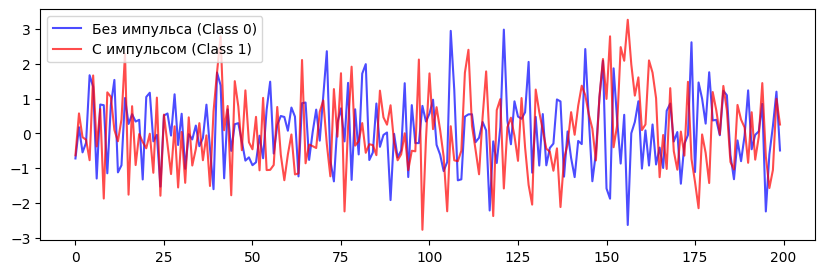

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [2]:
def generate_candidates(ts_list: np.ndarray, min_len: int = 3, max_len: int = 20) -> List[np.ndarray]:
    candidates = []
    seen = set()  # используем set для быстрой проверки уникальности
    
    n_samples, ts_length = ts_list.shape

    for i in range(n_samples):
        ts = ts_list[i]
        for length in range(min_len, min(max_len, ts_length) + 1):
            for start in range(ts_length - length + 1):
                candidate = ts[start:start + length]
                
                # Преобразуем в tuple для хранения в set (хешируемый тип)
                # Округляем для уменьшения количества уникальных кандидатов
                candidate_tuple = tuple(np.round(candidate, 6))
                
                if candidate_tuple not in seen:
                    seen.add(candidate_tuple)
                    candidates.append(candidate)
    
    return candidates

## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [3]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    # TODO: Z-score нормализация (обработать деление на ноль: вернем массив нулей, если std = 0)
    std = np.std(ts)
    if std == 0:
        return np.zeros_like(ts, dtype=float)
    return (ts - np.mean(ts)) / std

def calculate_shapelet_distance(shapelet: np.ndarray, time_series: np.ndarray) -> float:
    # TODO: Найти кратчайшее Евклидово расстояние между нормализованными сэмплами
    
    # нормализуем шейплет
    normalized_shapelet = z_normalize(shapelet)
    shapelet_len = len(normalized_shapelet)
    ts_len = len(time_series)
    
    # если шейплет длиннее ряда, возвращаем бесконечность
    if shapelet_len > ts_len:
        return float('inf')
    
    min_dist = float('inf')
    
    # скользящим окном проходим по всему ряду
    for i in range(ts_len - shapelet_len + 1):
        window = time_series[i:i + shapelet_len]
        normalized_window = z_normalize(window)
        # евклидово расстояние между шейплетом и окном
        dist = np.sqrt(np.sum((normalized_shapelet - normalized_window) ** 2))
        if dist < min_dist:
            min_dist = dist
    
    return min_dist

In [4]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

In [5]:
    # TODO:
    # 1. Извлечь кандидатов `generate_candidates` 
    # 2. Для каждого кандидата посчитать расстояния `calculate_shapelet_distance` ко всем временным рядам
    # 3. Высчитать `IG` для каждого `calculate_information_gain` (имеет смысл использовать `.sample()` для скорости)
    # 4. Отсортировать шейплеты по убыванию IG, взять топ K.
    # 5. Сформировать новую матрицу признаков из Distances лучших шейплетов
def shapelet_transform(X: np.ndarray, y: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    n_samples = X.shape[0]
    
    # 1. Извлекаем кандидатов с ОГРАНИЧЕНИЕМ количества
    print("Генерация кандидатов-шейплетов...")
    candidates = generate_candidates(X, min_len=3, max_len=15)  # Уменьшил max_len
    print(f"Сгенерировано кандидатов: {len(candidates)}")
    
    # Если кандидатов всё ещё много - берем случайную подвыборку
    max_candidates_to_test = 200
    if len(candidates) > max_candidates_to_test:
        indices = np.random.choice(len(candidates), max_candidates_to_test, replace=False)
        candidates = [candidates[i] for i in indices]
        print(f"Для ускорения взято {len(candidates)} случайных кандидатов")
    
    # Для ускорения используем подвыборку рядов
    sample_size = min(30, n_samples)  # Уменьшил до 30
    sample_indices = np.random.choice(n_samples, sample_size, replace=False)
    X_sample = X[sample_indices]
    y_sample = y[sample_indices]
    
    # 2. Для каждого кандидата вычисляем расстояния и IG
    shapelet_scores = []
    
    # Предварительная нормализация рядов из выборки
    normalized_series = [z_normalize(ts) for ts in X_sample]
    
    for idx, shapelet in enumerate(candidates):
        normalized_shapelet = z_normalize(shapelet)
        shapelet_len = len(normalized_shapelet)
        
        distances = np.zeros(sample_size)
        
        for i in range(sample_size):
            ts_normalized = normalized_series[i]
            ts_len = len(ts_normalized)
            
            if shapelet_len > ts_len:
                distances[i] = float('inf')
                continue
            
            min_dist = float('inf')
            # Используем векторизованные операции для ускорения
            for j in range(ts_len - shapelet_len + 1):
                window = ts_normalized[j:j + shapelet_len]
                dist = np.sqrt(np.sum((normalized_shapelet - window) ** 2))
                if dist < min_dist:
                    min_dist = dist
                    if min_dist == 0:
                        break
            distances[i] = min_dist
        
        ig, best_split = calculate_information_gain(distances, y_sample)
        
        shapelet_scores.append({
            'shapelet': shapelet,
            'ig': ig,
            'best_split': best_split
        })
        
        if (idx + 1) % 50 == 0:
            print(f"Обработано {idx + 1}/{len(candidates)} кандидатов")
    
    # 3. Сортируем по убыванию IG и берем top_k
    shapelet_scores.sort(key=lambda x: x['ig'], reverse=True)
    top_shapelets = shapelet_scores[:top_k]
    
    print(f"Выбрано {len(top_shapelets)} лучших шейплетов")
    for i, s in enumerate(top_shapelets):
        print(f"  {i+1}. IG = {s['ig']:.4f}, длина = {len(s['shapelet'])}")
    
    # 4. Формируем матрицу признаков для ВСЕХ рядов
    features = np.zeros((n_samples, top_k))
    
    print("Вычисление финальных расстояний для всех рядов...")
    for k, shapelet_info in enumerate(top_shapelets):
        shapelet = shapelet_info['shapelet']
        normalized_shapelet = z_normalize(shapelet)
        shapelet_len = len(normalized_shapelet)
        
        for i in range(n_samples):
            ts_normalized = z_normalize(X[i])
            ts_len = len(ts_normalized)
            
            if shapelet_len > ts_len:
                features[i, k] = float('inf')
                continue
            
            min_dist = float('inf')
            for j in range(ts_len - shapelet_len + 1):
                window = ts_normalized[j:j + shapelet_len]
                dist = np.sqrt(np.sum((normalized_shapelet - window) ** 2))
                if dist < min_dist:
                    min_dist = dist
            features[i, k] = min_dist
        
        print(f"  Признак {k+1}/{top_k} готов")
    
    return features, top_shapelets

Генерация кандидатов-шейплетов...
Сгенерировано кандидатов: 124800
Для ускорения взято 200 случайных кандидатов
Обработано 50/200 кандидатов
Обработано 100/200 кандидатов
Обработано 150/200 кандидатов
Обработано 200/200 кандидатов
Выбрано 5 лучших шейплетов
  1. IG = 0.3171, длина = 3
  2. IG = 0.2622, длина = 13
  3. IG = 0.2565, длина = 12
  4. IG = 0.2177, длина = 12
  5. IG = 0.2129, длина = 3
Вычисление финальных расстояний для всех рядов...
  Признак 1/5 готов
  Признак 2/5 готов
  Признак 3/5 готов
  Признак 4/5 готов
  Признак 5/5 готов
Форма новых признаков: (50, 5)
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.88      1.00      0.93         7

    accuracy                           0.93        15
   macro avg       0.94      0.94      0.93        15
weighted avg       0.94      0.93      0.93        15



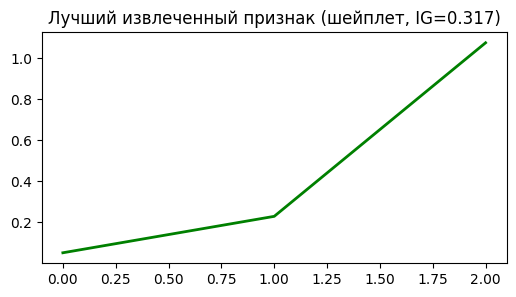

In [6]:
# Итоговое тестирование и Классификация
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features, top_shapelets = shapelet_transform(X, y, top_k=5)
print(f"Форма новых признаков: {features.shape}")

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6, 3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший извлеченный признак (шейплет, IG={top_shapelets[0]['ig']:.3f})")
plt.show()